In [ ]:
import sys
import os
sys.path.append(os.path.abspath(".."))
import numpy as np 
import pandas as pd
import datetime
import xarray as xr 
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import calendar
from zhiyi.analysis.SE_analysis import get_site_index 
from matplotlib.lines import Line2D
from scipy.spatial import cKDTree
import datetime as dt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.legend_handler import HandlerTuple
from matplotlib.legend_handler import HandlerBase
from matplotlib.patches import Rectangle
from matplotlib.font_manager import FontProperties
from matplotlib.ticker import MultipleLocator, AutoMinorLocator

print("done")

done


In [ ]:

# SCRIP
SCRIP_file = "/home/users/zhiyi/MUSICA_GRIDS/ne0np4.UK_ne30x16/grids/UK_ne30x16_np4_SCRIP.nc"
SCRIP_file_ne60 ="/home/users/zhiyi/MUSICA_GRIDS/ne0np4.UK_ne60/grids/UK_ne60_np4_SCRIP.nc"

filebase_ne30 = ('/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICA_production3.2_BB/atm/hist/'
                 'MUSICA_production3.2_BB.cam.h2.2018-MM-DD-03600.nc')
filebase_ne60 = ('/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICAv0_ne60_production/atm/hist/'
                 'MUSICAv0_ne60_production.cam.h2.2018-MM-DD-03600.nc')

start_date = datetime.date(2018, 5, 22)
end_date   = datetime.date(2018, 6, 15)

city_lonlat = {
    'London':    [360 - 0.213492,  51.521050],
    'Manchester':[360 - 2.237881, 53.481520],
    # 'Edingurgh': [360 - 3.182186, 55.945589],
    'Glasgow':   [360 - 4.259122, 55.858940],
    'Birmingham': [360 - 1.874978, 52.476145],
    # 'Belfast':   [360 - 5.9301, 54.5973],
    # 'Glasgow':   [360 - 4.2576, 55.8651],
    # 'Bristol':   [360 - 2.5879, 51.4545],
}

In [ ]:
def collect_files(template, start, end):
    files = []
    cur = start
    while cur <= end:
        f = (template
             .replace("MM", cur.strftime("%m"))
             .replace("DD", cur.strftime("%d")))
        if os.path.exists(f):
            files.append(f)
        else:
            print(f"Warning: File not found - {f}, skipping.")
        cur += datetime.timedelta(days=1)
    return files

def get_obs_series(obs_df, station_to_col, station, start, end):
    col = station_to_col[station]
    s = pd.to_numeric(obs_df[col], errors='coerce') 
    return s[start:end]

def build_kdtree(ds):
    lon360 = ds['lon'].isel(time=0).values
    lat    = ds['lat'].isel(time=0).values
    lon180 = (lon360 + 180) % 360 - 180
    tree   = cKDTree(np.vstack([lat, lon180]).T)
    return tree, lon360, lat, lon180

def get_3x3_minmax(ds, tree, lon180_all, city_lon, city_lat, k=9):
    lon180_c = (city_lon + 180) % 360 - 180
    _, idx9  = tree.query([city_lat, lon180_c], k=k)
    pm9 = ds['O3'][:, -1, idx9].values * 1e9
    return np.nanmin(pm9, axis=1), np.nanmax(pm9, axis=1)

scrip30 = xr.open_dataset(SCRIP_file)
scrip60 = xr.open_dataset(SCRIP_file_ne60)

se_files_30 = collect_files(filebase_ne30, start_date, end_date)
se_files_60 = collect_files(filebase_ne60, start_date, end_date)

ds_ne30 = xr.open_mfdataset(se_files_30, combine="by_coords")
ds_ne60 = xr.open_mfdataset(se_files_60, combine="by_coords")

print("Datasets loaded!")

Datasets loaded!


In [ ]:
Index_lonlat_30 = {}
Index_lonlat_60 = {}

for city, (lon360_c, lat_c) in city_lonlat.items():
    Index_lonlat_30[city] = get_site_index(
        lon360_c, lat_c,
        scrip_file=SCRIP_file
    )
    Index_lonlat_60[city] = get_site_index(
        lon360_c, lat_c,
        scrip_file=SCRIP_file_ne60
    )

TS     = {}
TS_f09 = {}
for city in city_lonlat:
    idx30 = Index_lonlat_30[city]
    idx60 = Index_lonlat_60[city]
    TS[city]     = ds_ne30['O3'].values[:, -1, idx30] * 1e9
    TS_f09[city] = ds_ne60['O3'].values[:, -1, idx60] * 1e9

time_values      = pd.to_datetime(ds_ne30.time.values)
time_values_nobb = pd.to_datetime(ds_ne60.time.values)

tree_30, lon360_30, lat_30, lon180_30 = build_kdtree(ds_ne30)
tree_60, lon360_60, lat_60, lon180_60 = build_kdtree(ds_ne60)

pm_min_30   = {}
pm_max_30   = {}
pm_min_60   = {}
pm_max_60   = {}
for city, (lon_c, lat_c) in city_lonlat.items():
    mn30, mx30 = get_3x3_minmax(
        ds_ne30, tree_30, lon180_30, lon_c, lat_c, k=36)
    mn60, mx60 = get_3x3_minmax(
        ds_ne60, tree_60, lon180_60, lon_c, lat_c, k=2)
    pm_min_30[city], pm_max_30[city] = mn30, mx30
    pm_min_60[city], pm_max_60[city] = mn60, mx60


In [ ]:
cities = list(city_lonlat.keys())
fig, axes = plt.subplots(4, 1, figsize=(15, 10))
day_locator   = mdates.DayLocator(interval=1)
day_formatter = mdates.DateFormatter('%m-%d')

obs = pd.read_csv('/home/users/zhiyi/PROJECTS_ANALYSIS/preprocess_obs_data/processed_data/london_o3.csv')
obs['Date'] = pd.to_datetime(obs['Date'].astype(str) + ' ' + obs['Time'].astype(str), errors='coerce')
ycol = 'average'
start_date = pd.to_datetime('2018-05-22')
end_date   = pd.to_datetime('2018-06-14')
obs_sel = obs[(obs['Date'] >= start_date) & (obs['Date'] <= end_date)].sort_values('Date')

obs_man = pd.read_csv('/home/users/zhiyi/PROJECTS_ANALYSIS/preprocess_obs_data/processed_data/manchester_o3.csv')
obs_man['Date'] = pd.to_datetime(obs_man['Date'].astype(str) + ' ' + obs_man['Time'].astype(str), errors='coerce')
ycol = 'average'
start_date = pd.to_datetime('2018-05-22')
end_date   = pd.to_datetime('2018-06-14')
obs_sel_man = obs_man[(obs_man['Date'] >= start_date) & (obs_man['Date'] <= end_date)].sort_values('Date')

obs_gla = pd.read_csv('/home/users/zhiyi/PROJECTS_ANALYSIS/preprocess_obs_data/processed_data/glasgow_o3.csv')
obs_gla['Date'] = pd.to_datetime(obs_gla['Date'].astype(str) + ' ' + obs_gla['Time'].astype(str), errors='coerce')
ycol = 'average'
start_date = pd.to_datetime('2018-05-22')
end_date   = pd.to_datetime('2018-06-14')
obs_sel_gla = obs_gla[(obs_gla['Date'] >= start_date) & (obs_gla['Date'] <= end_date)].sort_values('Date')

obs_bir = pd.read_csv('/home/users/zhiyi/PROJECTS_ANALYSIS/preprocess_obs_data/processed_data/birmingham_o3.csv')
obs_bir['Date'] = pd.to_datetime(obs_bir['Date'].astype(str) + ' ' + obs_bir['Time'].astype(str), errors='coerce')
ycol = 'average'
start_date = pd.to_datetime('2018-05-22')
end_date   = pd.to_datetime('2018-06-14')
obs_sel_bir = obs_bir[(obs_bir['Date'] >= start_date) & (obs_bir['Date'] <= end_date)].sort_values('Date')

time_values_bst = (pd.to_datetime(time_values.astype('datetime64[ns]'))
                   .tz_localize('UTC')
                   .tz_convert('Europe/London'))
time_values_nobb_bst = (pd.to_datetime(time_values_nobb.astype('datetime64[ns]'))
                        .tz_localize('UTC')
                        .tz_convert('Europe/London'))

for i, city in enumerate(cities):
    ax = axes[i]
    ax.fill_between(time_values_bst,      pm_min_30[city], pm_max_30[city], alpha=0.4 , color='salmon')
    ax.plot(time_values_bst,      TS[city].squeeze(),    color='coral', linewidth=2.5, label='ne30x16')   
    ax.fill_between(time_values_nobb_bst, pm_min_60[city], pm_max_60[city], alpha=0.4,color='cornflowerblue')
    ax.plot(time_values_nobb_bst, TS_f09[city].squeeze(), color='royalblue', linewidth=2.5, label='ne60')
    
    ax.axvspan(pd.to_datetime('2018-05-27'), pd.to_datetime('2018-06-02'),
            color='green', alpha=0.15, zorder=0)
    
    if i == 0:
        ax.plot(
            obs_sel['Date'], obs_sel[ycol] * 0.5033,
            color='black', linewidth=2.5, alpha=0.9,
            label='AURN Obs'
        )
        ax.legend(fontsize=20, loc='upper right')
    elif i == 1:  
        ax.plot(
            obs_sel_man['Date'], obs_sel_man[ycol] * 0.5007,
            color='black', linewidth=2.5, alpha=0.9,
            label='AURN Obs'
        )
    elif i == 2:  
        ax.plot(
            obs_sel_gla['Date'], obs_sel_gla[ycol] * 0.4976,
            color='black', linewidth=2.5, alpha=0.9,
            label='AURN Obs'
        )
    elif i == 3:  
        ax.plot(
            obs_sel_bir['Date'], obs_sel_bir[ycol] * 0.5005,
            color='black', linewidth=2.5, alpha=0.9,
            label='AURN Obs'
        )
    ax.set_title(city, fontsize=22)
    ax.xaxis.set_major_locator(day_locator)
    ax.xaxis.set_major_formatter(day_formatter)
    ax.set_xlim(pd.to_datetime('2018-05-22'), pd.to_datetime('2018-06-14'))

    plt.setp(ax.get_yticklabels(), fontsize=20)
    if i in [0, 1, 2]:
        ax.tick_params(axis='x', which='both', labelbottom=False)
        ax.set_xticks([])
    else:
        plt.setp(ax.get_xticklabels(), rotation=0, fontsize=20)
        ax.set_xlabel('Date', fontsize=20)
        ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
        
        ax.xaxis.set_minor_locator(AutoMinorLocator(2))    
        ax.tick_params(axis='x', which='major', labelsize=22, pad=9, length=8, width=1)
        ax.tick_params(axis='x', which='minor', labelsize=18*0.8, length=4, width=1)
    
    if i == 0:
            title_str = r'(f)'           
            ax.text(
                0, 1.12,                               
                title_str,
                transform=ax.transAxes,
                fontsize=25, va='bottom', ha='left',
                weight='bold', 
                zorder=10) 

    ax.set_ylabel('O$_{3}$ (ppbv)', fontsize=20)
    ax.yaxis.set_major_locator(MultipleLocator(18))
    ax.yaxis.set_minor_locator(AutoMinorLocator(2)) 
    ax.set_ylim(0, 73)
    ax.yaxis.set_minor_locator(AutoMinorLocator(2))
    ax.tick_params(axis='y', which='major', labelsize=20, pad=9, length=8, width=1, )
    ax.tick_params(axis='y', which='minor', labelsize=18*0.8, length=4, width=1)
    axes[0].legend(fontsize=13, loc='upper right')
    
plt.tight_layout(h_pad=0.1)

/tmp/ipykernel_476980/811768895.py:42: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  obs_use['Date'] = obs_use['Date'].dt.round('H')
/tmp/ipykernel_476980/811768895.py:52: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_mod30['Date'] = pd.to_datetime(df_mod30['Date']).dt.round('H')
/tmp/ipykernel_476980/811768895.py:53: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_mod60['Date'] = pd.to_datetime(df_mod60['Date']).dt.round('H')
/tmp/ipykernel_476980/811768895.py:42: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  obs_use['Date'] = obs_use['Date'].dt.round('H')
/tmp/ipykernel_476980/811768895.py:52: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_mod30['Date'] = pd.to_datetime(df_mod30['Date']).dt.round('H')
/tmp/ipyker

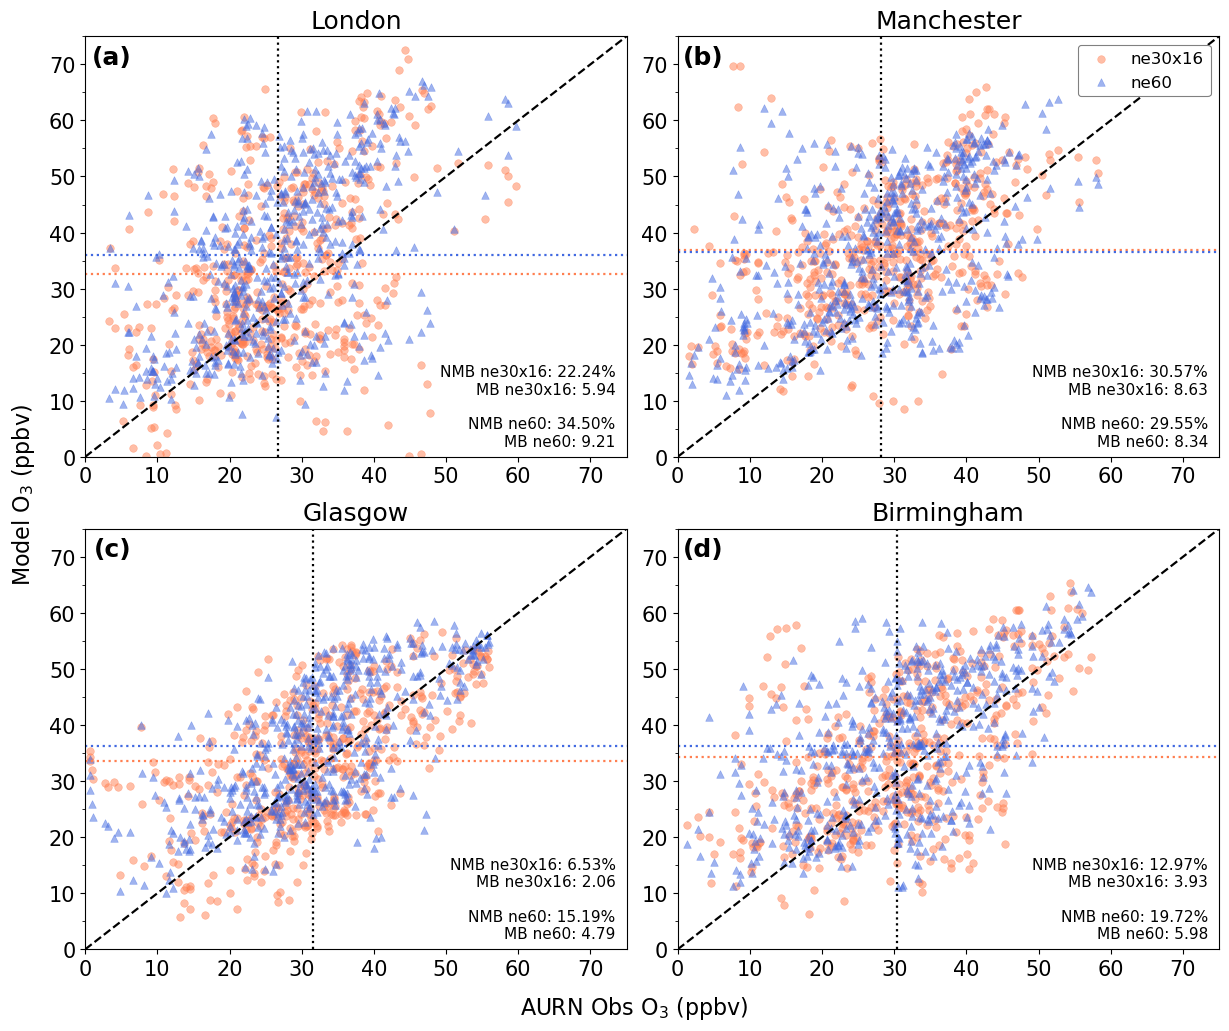

In [ ]:

time_values_bst_naive      = pd.DatetimeIndex(time_values_bst).tz_localize(None)
time_values_nobb_bst_naive = pd.DatetimeIndex(time_values_nobb_bst).tz_localize(None)

# ug/m3 to ppbv
ycol = 'average'
obs_dict = {
    'London':     (obs_sel,     0.5033),
    'Manchester': (obs_sel_man, 0.5007),
    'Glasgow':    (obs_sel_gla, 0.4976),
    'Birmingham': (obs_sel_bir, 0.5005),
}

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

lim_min, lim_max = 0, 75
xs = np.linspace(lim_min, lim_max, 200)

def nmb(model, obs):
    return 100.0 * (np.nansum(model - obs) / np.nansum(obs))

def rmse(model, obs):
    return np.sqrt(np.nanmean((model - obs) ** 2))

def corr_r(model, obs):
    if len(model) < 2:
        return np.nan
    return np.corrcoef(obs, model)[0, 1]
def mb(model, obs):
    return np.nanmean(model - obs)

for i, city in enumerate(cities):
    ax = axes[i]
    obs_df, factor = obs_dict[city]

    obs_use = obs_df[['Date', ycol]].dropna().copy()
    obs_use['Date'] = obs_use['Date'].dt.round('H')

    df_mod30 = pd.DataFrame({
        'Date':    time_values_bst_naive,
        'model30': pd.Series(TS[city].squeeze()).astype(float).values
    })
    df_mod60 = pd.DataFrame({
        'Date':    time_values_nobb_bst_naive,
        'model60': pd.Series(TS_f09[city].squeeze()).astype(float).values
    })
    df_mod30['Date'] = pd.to_datetime(df_mod30['Date']).dt.round('H')
    df_mod60['Date'] = pd.to_datetime(df_mod60['Date']).dt.round('H')

    dfm = obs_use.merge(df_mod30, on='Date', how='inner')
    dfm = dfm.merge(df_mod60, on='Date', how='inner')

    dfm['obs_ppbv'] = dfm[ycol].astype(float) * factor

    dfm = dfm[['obs_ppbv', 'model30', 'model60']].replace([np.inf, -np.inf], np.nan).dropna()
    x_obs = dfm['obs_ppbv'].values
    y_30  = dfm['model30'].values
    y_60  = dfm['model60'].values


    ax.plot([lim_min, lim_max], [lim_min, lim_max], '--', linewidth=1.6,color='k')


    obs_mean   = np.nanmean(x_obs)
    mod30_mean = np.nanmean(y_30)  
    mod60_mean = np.nanmean(y_60)   


    ax.axvline(obs_mean, linestyle=':', linewidth=1.6, color='k')

    ax.axhline(mod30_mean, linestyle=':', linewidth=1.6, color='coral')
    ax.axhline(mod60_mean, linestyle=':', linewidth=1.6, color='royalblue')

    ax.scatter(x_obs, y_30, s=30, alpha=0.5,
               label='ne30x16', linewidth=0.4, color='coral')
    ax.scatter(x_obs, y_60, s=30, alpha=0.5,
               label='ne60', marker='^',linewidth=0.4, color='royalblue')

    ax.set_xlim(lim_min, lim_max)
    ax.set_ylim(lim_min, lim_max)
    ax.set_title(city, fontsize=18)
    ax.grid(alpha=0.3)
    ax.yaxis.set_major_locator(MultipleLocator(10))
    ax.yaxis.set_minor_locator(AutoMinorLocator(2))

    mb30  = mb(y_30, x_obs)
    mb60  = mb(y_60, x_obs)
    nmb30 = nmb(y_30, x_obs)
    nmb60 = nmb(y_60, x_obs)
    rmse30 = rmse(y_30, x_obs)
    rmse60 = rmse(y_60, x_obs)
    corr30 = np.corrcoef(y_30, x_obs)[0, 1]
    corr60 = np.corrcoef(y_60, x_obs)[0, 1]

    stats_txt = (
        # f"R ne30x16: {corr30:.2f}%\n"
        f"NMB ne30x16: {nmb30:.2f}%\n"
        f"MB ne30x16: {mb30:.2f}\n\n"
    
        # f"R ne60: {corr60:.2f}%\n"
        f"NMB ne60: {nmb60:.2f}%\n"
        f"MB ne60: {mb60:.2f}\n"
    )

    ax.text(
        0.98, 0.22, stats_txt,
        transform=ax.transAxes,
        ha='right', va='top',
        fontsize=11,
        linespacing=1.2,
    )
    ax.grid(False)  
    if i == 1:
            leg = ax.legend(fontsize=12, loc='upper right', frameon=True)
            frame = leg.get_frame()
            frame.set_facecolor('white')
            frame.set_edgecolor('gray')  
            frame.set_linewidth(0.8)
            frame.set_alpha(1.0)
    
    
    ax.tick_params(axis='both', labelsize=15)

# axes[0].set_ylabel('Model O$_3$ (ppbv)', fontsize=14)
# axes[2].set_ylabel('Model O$_3$ (ppbv)', fontsize=14)
# axes[2].set_xlabel('Observed O$_3$ (ppbv)', fontsize=14)
# axes[3].set_xlabel('Observed O$_3$ (ppbv)', fontsize=14)

fig.text(0.5, -0.02, 'AURN Obs O$_3$ (ppbv)', ha='center', fontsize=16)
fig.text(-0.02, 0.5, 'Model O$_3$ (ppbv)', va='center', rotation='vertical', fontsize=16)

labels = ['(a)', '(b)', '(c)', '(d)']
for ax, label in zip(axes, labels):
    ax.text(
        0.085, 0.98, 
        label, 
        transform=ax.transAxes,
        fontsize=18,
        fontweight='bold',
        va='top', ha='right'
    )


plt.tight_layout()



/tmp/ipykernel_476980/1550429922.py:32: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  obs_use['Date'] = obs_use['Date'].dt.round('H')
/tmp/ipykernel_476980/1550429922.py:36: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df30['Date'] = pd.to_datetime(df30['Date']).dt.round('H')
/tmp/ipykernel_476980/1550429922.py:37: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df60['Date'] = pd.to_datetime(df60['Date']).dt.round('H')
/tmp/ipykernel_476980/1550429922.py:32: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  obs_use['Date'] = obs_use['Date'].dt.round('H')
/tmp/ipykernel_476980/1550429922.py:36: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df30['Date'] = pd.to_datetime(df30['Date']).dt.round('H')
/tmp/ipykernel_476980/15504299

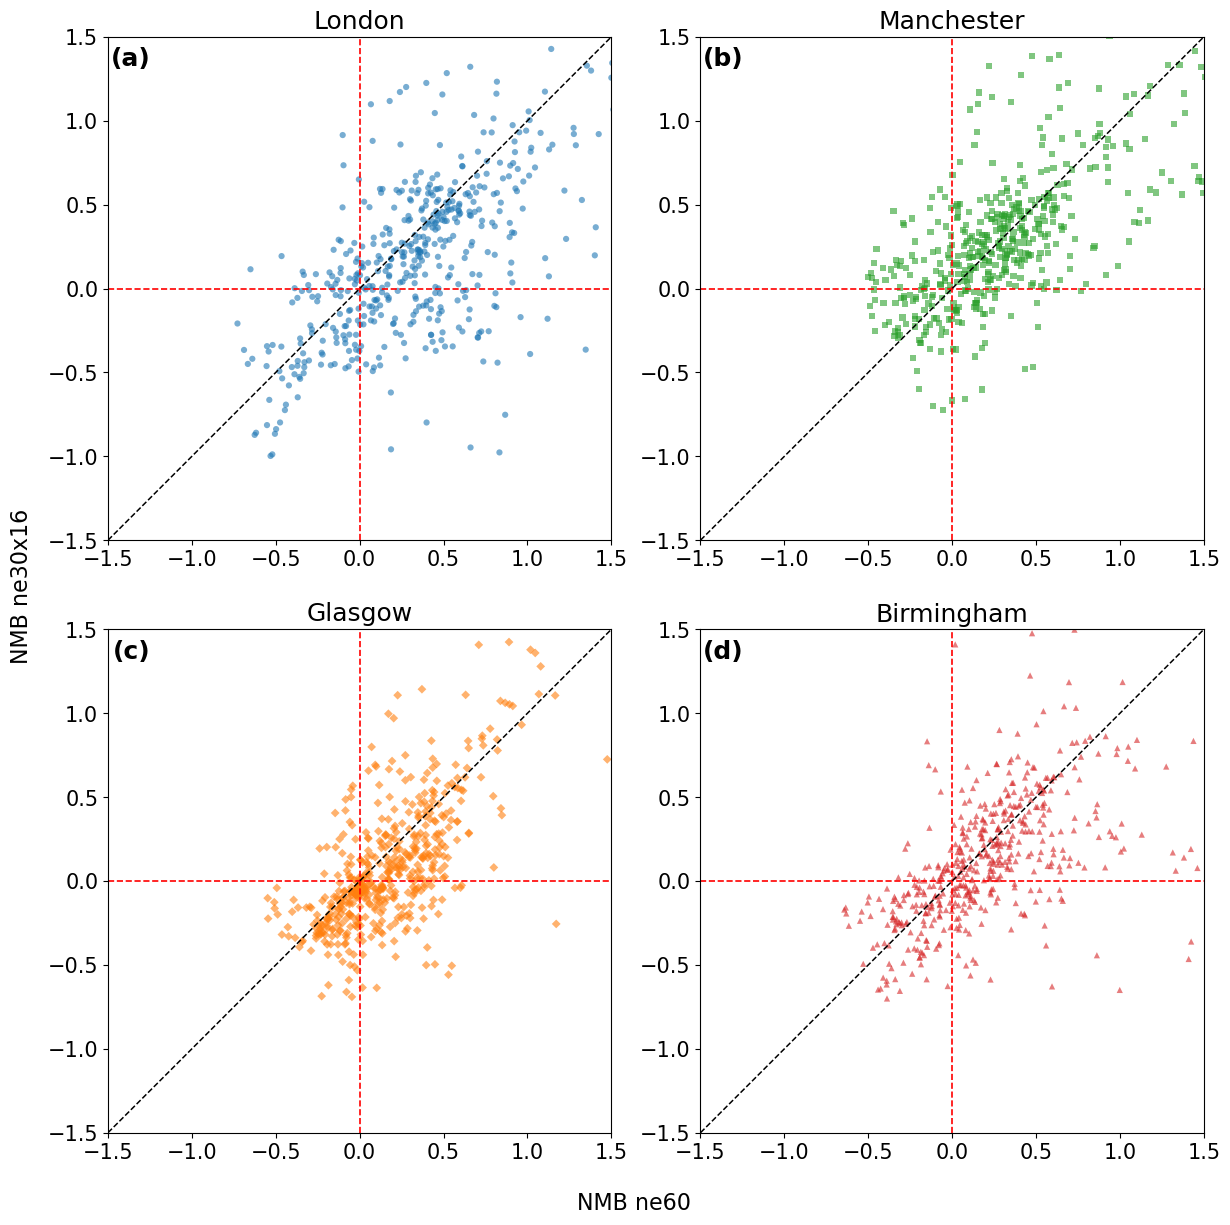

In [ ]:
ycol = 'average'
obs_dict = {
    'London':     (obs_sel,     0.5033),
    'Manchester': (obs_sel_man, 0.5007),
    'Glasgow':    (obs_sel_gla, 0.4976),
    'Birmingham': (obs_sel_bir, 0.5005),
}

time_values_bst_naive      = pd.DatetimeIndex(time_values_bst).tz_localize(None)
time_values_nobb_bst_naive = pd.DatetimeIndex(time_values_nobb_bst).tz_localize(None)

def nmb_series(model, obs):
    with np.errstate(divide='ignore', invalid='ignore'):
        return (model - obs) / obs 

fig, axes = plt.subplots(2, 2, figsize=(12, 12))
axes = axes.flatten()

style = {
    'London':     dict(color='tab:blue',   marker='o'),
    'Manchester': dict(color='tab:green',  marker='s'),
    'Glasgow':    dict(color='tab:orange', marker='D'),
    'Birmingham': dict(color='tab:red',    marker='^'),
}

for i, city in enumerate(cities):

    ax = axes[i]
    obs_df, factor = obs_dict[city]

    obs_use = obs_df[['Date', ycol]].dropna().copy()
    obs_use['Date'] = obs_use['Date'].dt.round('H')

    df30 = pd.DataFrame({'Date': time_values_bst_naive,   'm30': TS[city].squeeze()})
    df60 = pd.DataFrame({'Date': time_values_nobb_bst_naive, 'm60': TS_f09[city].squeeze()})
    df30['Date'] = pd.to_datetime(df30['Date']).dt.round('H')
    df60['Date'] = pd.to_datetime(df60['Date']).dt.round('H')

    dfm = obs_use.merge(df30, on='Date', how='inner').merge(df60, on='Date', how='inner')
    dfm['obs'] = dfm[ycol] * factor
    dfm = dfm[['obs','m30','m60']].replace([np.inf,-np.inf], np.nan).dropna()

    obs   = dfm['obs'].values
    mod30 = dfm['m30'].values
    mod60 = dfm['m60'].values

    x_nmb60 = nmb_series(mod60, obs)
    y_nmb30 = nmb_series(mod30, obs)

    mask = np.isfinite(x_nmb60) & np.isfinite(y_nmb30)
    x_nmb60, y_nmb30 = x_nmb60[mask], y_nmb30[mask]

    lim_raw = max(np.nanmax(np.abs(x_nmb60)), np.nanmax(np.abs(y_nmb30)))
    lim = max(0.8, min(1.5, np.ceil((lim_raw+0.05)*10)/10))

    ax.axvline(0, color='red', linestyle='--', linewidth=1.2)
    ax.axhline(0, color='red', linestyle='--', linewidth=1.2)
    ax.plot([-lim, lim], [-lim, lim], linestyle='--', color='black', linewidth=1.1)

    st = style[city]
    ax.scatter(x_nmb60, y_nmb30, s=20, alpha=0.6, edgecolor='none', **st)

    ax.set_title(city, fontsize=18)
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_aspect('equal', 'box')
    ax.grid(False)

    ax.tick_params(axis='both', labelsize=15)

fig.text(0.5, -0.02, 'NMB ne60', ha='center', fontsize=16)
fig.text(-0.02, 0.5, 'NMB ne30x16', va='center', rotation='vertical', fontsize=16)


labels = ['(a)', '(b)', '(c)', '(d)']
for ax, label in zip(axes, labels):
    ax.text(
        0.085, 0.98,
        label, 
        transform=ax.transAxes,
        fontsize=18,
        fontweight='bold',
        va='top', ha='right'
    )

plt.tight_layout()
